In [21]:
import sys
sys.path.insert(0, '../Week-5-6-7-8')

import json
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, NuSVR

from helpers.modeling import identify_column_types, create_preprocessor
from uncertainty import run_conformal, calibration_table, prepare_data_group

with open('../Week-5-6-7-8/results.json', 'r') as f:
    results = json.load(f)

df = pd.read_csv("../Datasets/processed/UHPC_dataset/semantic_recoding_features_50_with_publications.csv")

In [22]:
target_col = 'cs_28d'

# Group-aware split: no publication bleeds across train / val / test
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data_group(
    df, target_col, group_col='paper_reference'
)

pub_train = df.loc[X_train.index, 'paper_reference']
pub_test = df.loc[X_test.index, 'paper_reference']
pub_val  = df.loc[X_val.index,  'paper_reference']

print(f"Train size : {X_train.shape[0]}  ({pub_train.nunique()} publications)")
print(f"Val size   : {X_val.shape[0]}  ({pub_val.nunique()} publications)")
print(f"Test size  : {X_test.shape[0]}  ({pub_test.nunique()} publications)")

numerical_cols, one_hot_columns, k_fold_columns = identify_column_types(X_train)
preprocessor = create_preprocessor(numerical_cols, one_hot_columns, k_fold_columns,
                                   handle_unknown='ignore')
print(f"\nEncoded training shape: {preprocessor.fit_transform(X_train, y_train).shape}")

Train size : 1461  (115 publications)
Val size   : 329  (25 publications)
Test size  : 283  (25 publications)

Encoded training shape: (1461, 69)


In [23]:
pipeline_knn, train_knn, test_knn, q_knn, intervals_knn, calibration_knn = run_conformal(
    KNeighborsRegressor, 'knn', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_knn}")
print(f"Test:  {test_knn}")
print(f"Conformal q (90%): {q_knn:.2f}")
calibration_knn

Train: {'RMSE': np.float64(6.4341212920603015), 'MAE': 3.6294436384032758, 'R2': 0.9615064723975191, 'Correlation': np.float64(0.9806141704525441), 'Mean_Residual': np.float64(0.021705218155136048), 'N': 1461}
Test:  {'RMSE': np.float64(23.172645976354353), 'MAE': 17.51359797089775, 'R2': 0.4043523934244718, 'Correlation': np.float64(0.7269637050599429), 'Mean_Residual': np.float64(-7.481242967320217), 'N': 283}
Conformal q (90%): 74.71


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-107-Research,16,109.031250,111.460407,1.0,149.42085,7.417030,15.027680
1,Ref-11-Research,4,127.750000,116.691008,1.0,149.42085,11.058992,9.893044
2,Ref-113-Research,5,165.055660,170.084117,1.0,149.42085,8.302693,5.917821
3,Ref-114-Research,5,208.804000,193.012444,1.0,149.42085,16.184460,5.925091
4,Ref-116-Research,36,152.627778,154.830362,1.0,149.42085,4.227329,4.000198
5,Ref-117-Research,5,113.000000,116.308565,1.0,149.42085,13.682016,17.694183
6,Ref-121-Research,80,165.075000,183.375066,1.0,149.42085,23.302892,8.701904
7,Ref-126-Research,5,114.600000,151.253373,1.0,149.42085,36.653373,5.846987
8,Ref-127-Research,3,201.200000,153.286657,1.0,149.42085,47.913343,4.654296
9,Ref-128-Research,3,201.266667,200.338782,1.0,149.42085,2.390650,3.528081


In [24]:
pipeline_svr, train_svr, test_svr, q_svr, intervals_svr, calibration_svr = run_conformal(
    SVR, 'svr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_svr}")
print(f"Test:  {test_svr}")
print(f"Conformal q (90%): {q_svr:.2f}")
calibration_svr

Train: {'RMSE': np.float64(8.350698902667224), 'MAE': 5.4262670464789835, 'R2': 0.9351582280359648, 'Correlation': np.float64(0.9671334749549444), 'Mean_Residual': np.float64(-0.3008474423495124), 'N': 1461}
Test:  {'RMSE': np.float64(26.873355636669366), 'MAE': 20.590892089824067, 'R2': 0.19890882633328444, 'Correlation': np.float64(0.6354698303635938), 'Mean_Residual': np.float64(-5.502045060119226), 'N': 283}
Conformal q (90%): 85.96


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-107-Research,16,109.031250,121.398072,1.0,171.917735,20.371009,6.603812
1,Ref-11-Research,4,127.750000,124.197822,1.0,171.917735,6.078823,3.657911
2,Ref-113-Research,5,165.055660,163.891948,1.0,171.917735,2.372703,3.133513
3,Ref-114-Research,5,208.804000,187.665087,1.0,171.917735,23.196287,2.199910
4,Ref-116-Research,36,152.627778,144.194733,1.0,171.917735,8.433045,1.931497
5,Ref-117-Research,5,113.000000,127.359192,1.0,171.917735,14.359192,8.213811
6,Ref-121-Research,80,165.075000,171.893340,1.0,171.917735,15.871957,3.886346
7,Ref-126-Research,5,114.600000,169.177728,1.0,171.917735,54.577728,2.476713
8,Ref-127-Research,3,201.200000,149.370435,1.0,171.917735,51.829565,2.086538
9,Ref-128-Research,3,201.266667,207.626140,1.0,171.917735,6.359473,2.164416


In [25]:
pipeline_nusvr, train_nusvr, test_nusvr, q_nusvr, intervals_nusvr, calibration_nusvr = run_conformal(
    NuSVR, 'nusvr', results, 'recoded_50', preprocessor,
    X_train, y_train, X_val, y_val, X_test, y_test, pub_test
)
print(f"Train: {train_nusvr}")
print(f"Test:  {test_nusvr}")
print(f"Conformal q (90%): {q_nusvr:.2f}")
calibration_nusvr

Train: {'RMSE': np.float64(8.393411667565504), 'MAE': 5.570885517123313, 'R2': 0.9344932167843721, 'Correlation': np.float64(0.9667924682605202), 'Mean_Residual': np.float64(-0.3111168929884092), 'N': 1461}
Test:  {'RMSE': np.float64(25.866231005875115), 'MAE': 19.836822517859083, 'R2': 0.25782819528232703, 'Correlation': np.float64(0.6438112445306194), 'Mean_Residual': np.float64(-4.333842382312459), 'N': 283}
Conformal q (90%): 89.64


,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-107-Research,16,109.031250,123.745151,1.0,179.274503,19.561865,6.603287
1,Ref-11-Research,4,127.750000,120.833490,1.0,179.274503,7.285154,3.657767
2,Ref-113-Research,5,165.055660,161.808106,1.0,179.274503,3.727950,3.133504
3,Ref-114-Research,5,208.804000,184.826271,1.0,179.274503,25.658506,2.199811
4,Ref-116-Research,36,152.627778,144.722414,1.0,179.274503,7.905363,1.931497
5,Ref-117-Research,5,113.000000,127.096038,1.0,179.274503,14.096038,8.213798
6,Ref-121-Research,80,165.075000,168.742227,1.0,179.274503,15.263251,3.884259
7,Ref-126-Research,5,114.600000,160.069383,1.0,179.274503,45.469383,2.476714
8,Ref-127-Research,3,201.200000,147.605438,1.0,179.274503,53.594562,2.086623
9,Ref-128-Research,3,201.266667,202.505781,1.0,179.274503,3.384707,2.164416


In [26]:
poor_coverage_threshold = 1

poor_coverage = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
])
poor_coverage = (
    poor_coverage[poor_coverage['coverage'] < poor_coverage_threshold]
    .sort_values('coverage')
    [['model', 'publication', 'n_rows', 'coverage', 'interval_width', 'mean_residual', 'mean_distance']]
    .reset_index(drop=True)
)

print(f"Publications below {poor_coverage_threshold:.0%} coverage: {poor_coverage['publication'].nunique()} unique, {len(poor_coverage)} model-publication pairs")
poor_coverage

Publications below 100% coverage: 0 unique, 0 model-publication pairs


,model,publication,n_rows,coverage,interval_width,mean_residual,mean_distance


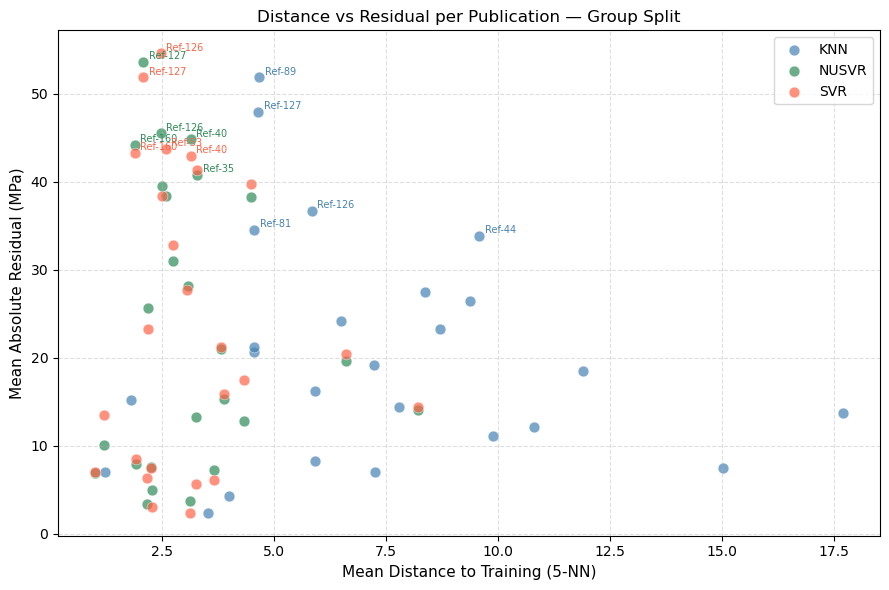

In [27]:
import matplotlib.pyplot as plt

all_cal = pd.concat([
    calibration_knn.assign(model='knn'),
    calibration_svr.assign(model='svr'),
    calibration_nusvr.assign(model='nusvr'),
], ignore_index=True)

colors = {'knn': 'steelblue', 'svr': 'tomato', 'nusvr': 'seagreen'}

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, grp in all_cal.groupby('model'):
    ax.scatter(grp['mean_distance'], grp['mean_residual'],
               label=model_name.upper(), color=colors[model_name],
               alpha=0.7, edgecolors='white', linewidths=0.4, s=60)

# label outliers: top 5 by mean_residual per model
for model_name, grp in all_cal.groupby('model'):
    for _, row in grp.nlargest(5, 'mean_residual').iterrows():
        ax.annotate(row['publication'].replace('-Research', '').replace('-data', ''),
                    xy=(row['mean_distance'], row['mean_residual']),
                    fontsize=7, color=colors[model_name],
                    xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Mean Distance to Training (5-NN)', fontsize=11)
ax.set_ylabel('Mean Absolute Residual (MPa)', fontsize=11)
ax.set_title('Distance vs Residual per Publication — Group Split', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [28]:
print(q_knn, q_svr, q_nusvr)

74.71042510108451 85.95886734241446 89.63725129676942
